# Francois Notebook --> Implementing Diffusion leveraging Jax much better than I did

In [1]:
import jax
import jax.numpy as jnp
from tensorflow_probability.substrates import jax as tfp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from diffrax import diffeqsolve, ControlTerm, Dopri5, Heun, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, WeaklyDiagonalControlTerm
import jax.random as jr
import lineax as lx
from pqm import pqm_chi2
import torch
from scipy.stats import norm, chi2, uniform
import numpyro.distributions as dist
JAX_DISABLE_JIT=1
jax.config.update("jax_enable_x64", True)

/Users/ss286538/miniconda3/envs/jax_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@jax.jit
def make_two_mooons(sigma):
  """
  Function that gives you the log probability of the two moons distribution.
  """
  resolution = 1024
  outer_circ_x = jnp.cos(jnp.linspace(0, jnp.pi, resolution))
  outer_circ_y = jnp.sin(jnp.linspace(0, jnp.pi, resolution))
  inner_circ_x = 1 - jnp.cos(jnp.linspace(0, jnp.pi, resolution))
  inner_circ_y = 1 - jnp.sin(jnp.linspace(0, jnp.pi, resolution)) - .5

  X = jnp.append(outer_circ_x, inner_circ_x)
  Y = jnp.append(outer_circ_y, inner_circ_y)
  coords = jnp.vstack([X,Y])

  base_sigma=0.05
  s = jnp.sqrt(sigma**2 + base_sigma**2)
  # We approximate the 2 moons with a large mixture
  distribution = dist.MixtureSameFamily(
      dist.Categorical(probs=jnp.ones(2*resolution)/resolution/2),
      dist.MultivariateNormal(loc=coords.T, scale_tril=s*jnp.eye(2)[None].repeat(2*resolution, axis=0))
  )
  return distribution


W0311 10:45:42.249233 9017923 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


(-1.0, 2.0)

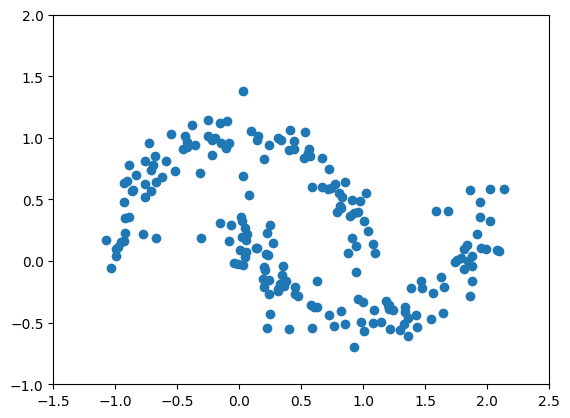

In [3]:
# Sample from the distribution and plot it
rng_key = jax.random.PRNGKey(seed=0)
distribution = make_two_mooons(0.1)
samps = distribution.sample(rng_key, sample_shape=(200,))

plt.scatter(samps[:,0], samps[:,1])
plt.xlim(-1.5,-1.5+4)
plt.ylim(-1.,-1.+3)

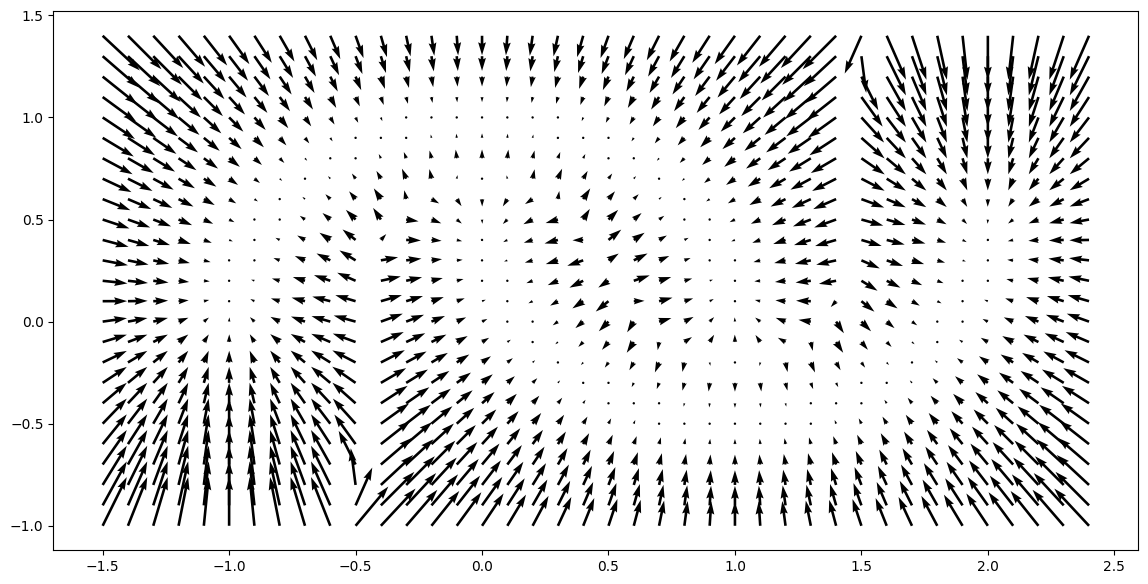

In [4]:
# But now we can also compute the gradients of log p :-)
grads = jax.vmap(jax.grad(distribution.log_prob))

X = jnp.arange(-1.5, 2.5, 0.1)
Y = jnp.arange(-1, 1.5, 0.1)
points = jnp.stack(jnp.meshgrid(X, Y), axis=-1).reshape((-1, 2))
g = grads(points).reshape([len(Y), len(X),2])

plt.figure(figsize=(14,7))
plt.quiver(X, Y, g[:,:,0], g[:,:,1]);

# Implementation of a diffusion model

In [5]:
import jax
import jax.numpy as jnp
import diffrax
import lineax as lx

def log_p(x, sigma=0.):
  return make_two_mooons(sigma).log_prob(x).squeeze()

score_fn = jax.vmap(jax.grad(log_p), in_axes=(0,None))

def ve_sde_sample(score_fn, x_init, key, sigma_min=0.01, sigma_max=10.0, N=128):
    """Sample from a VE-SDE diffusion model via reverse-time SDE.

    Forward VE-SDE:  dx = sqrt(d[sigma^2(t)]/dt) dw
    Reverse VE-SDE:  dx = -sigma(t)^2 * score(x, t) dt + sigma(t) dw_bar

    with sigma(t) = sigma_min * (sigma_max/sigma_min)^t
    """

    def sigma(t):
        return sigma_min * (sigma_max / sigma_min) ** t

    def drift(t, y, args):
        s = sigma(t)
        # d[sigma^2]/dt = sigma^2 * 2*log(sigma_max/sigma_min)
        score = score_fn(y, s)
        return -s**2 * 2 * jnp.log(sigma_max / sigma_min) * score

    def diffusion(t, y, args):
        s = sigma(t)
        diffusion_coeff_scalar = s * jnp.sqrt(2 * jnp.log(sigma_max / sigma_min))
        # Return a Lineax DiagonalLinearOperator as recommended by Diffrax 0.7.0+
        diagonal = jnp.full(y.shape[-1], diffusion_coeff_scalar) # Create a diagonal vector of size num_dims
        return lx.DiagonalLinearOperator(diagonal)

    # Reverse time: integrate from t=1 to t=0
    brownian_motion = diffrax.VirtualBrownianTree(
        t0=0.0, t1=1.0, tol=1e-3, shape=x_init.shape, key=key
    )

    terms = diffrax.MultiTerm(
        diffrax.ODETerm(drift),
        diffrax.ControlTerm(diffusion, brownian_motion),
    )

    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        terms,
        solver,
        t0=1.0,
        t1=0.0,
        dt0=-0.005, #-1.0 / N,
        y0=x_init,
        args=None,
        saveat=diffrax.SaveAt(ts=jnp.linspace(1.0, 0.0, N))
    )

    return sol.ys

key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
x_init = jax.random.normal(k1, (2000,2))  # start from noise

sample_score_fn = jax.vmap(jax.grad(log_p), in_axes=(0,None))

samples = ve_sde_sample(sample_score_fn, x_init, k2)

In [12]:
import imageio
import numpy as np

frames = []
for i in range(samples.shape[0]):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(samples[i, :, 0], samples[i, :, 1], alpha=0.5)
    ax.set_xlim(-1.5, 2.5)
    ax.set_ylim(-1, 1.5)
    ax.set_title(f'Iteration {i}')
    fig.canvas.draw()
    width, height = fig.canvas.get_width_height()
    image = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(height, width, 4)[..., :3]
    frames.append(image)
    plt.close(fig)

imageio.mimsave('diffusion_evolution.gif', frames, fps=10)

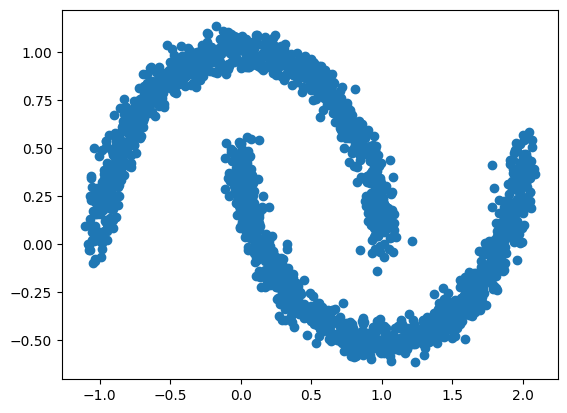

In [7]:
plt.scatter(samples[-1,:,0], samples[-1,:,1])

In [13]:
def run_pqm(sample_A, sample_B):
    all_data = torch.cat([torch.Tensor(sample_A), torch.Tensor(sample_B)], dim=0).detach().numpy()
    np.random.shuffle(all_data)

    x_samples = torch.tensor(all_data[:len(all_data)//2], device = 'mps')
    y_samples = torch.tensor(all_data[len(all_data)//2:], device = 'mps')

    x_np = x_samples.cpu().numpy()
    y_np = y_samples.cpu().numpy()

    zs = []

    for i in range(1000):
        z = pqm_chi2(x_np, y_np, num_refs=50, gauss_frac=1.0)
        zs += [z]
    return zs

# Define Ideal Chi2 For Plotting
df = 49
mean = df
std = np.sqrt(2 * df)

# Plot range: mean ± 4 standard deviations (captures ~99.99% of distribution)
x_min = max(0, mean - 4 * std)
x_max = mean + 4 * std
ideal_chi2 = np.linspace(x_min, x_max, 500)

In [14]:
samps.shape, samples[-1].shape

((200, 2), (2000, 2))

In [15]:
# convert from jax to numpy
import numpy as onp  # standard numpy, to avoid confusion with jax.numpy as np

samps_np = onp.array(samps)
samples_np = onp.array(samples)

print(f'Type of samps_np: {type(samps_np)}')
print(f'Type of samples_np: {type(samples_np)}')

samps_torch = torch.Tensor(samps_np)
samples_torch = torch.Tensor(samples_np)

print(f'Type of samps_torch: {type(samps_torch)}')
print(f'Type of samples_torch: {type(samples_torch)}')

Type of samps_np: <class 'numpy.ndarray'>
Type of samples_np: <class 'numpy.ndarray'>
Type of samps_torch: <class 'torch.Tensor'>
Type of samples_torch: <class 'torch.Tensor'>


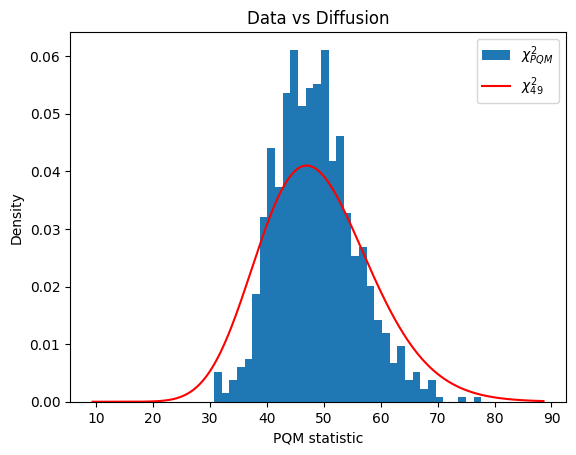

In [18]:
zs_result_reverse_pass = run_pqm(samps_torch, samples_torch[-1])

fig, axes = plt.subplots()

plt.hist(zs_result_reverse_pass, bins=35, density=True, label=r'$\chi^2_{PQM}$')
plt.plot(ideal_chi2, chi2.pdf(ideal_chi2, df=49), color='red', label=r'$\chi^2_{49}$')
plt.xlabel('PQM statistic')
plt.ylabel('Density')
plt.title('Data vs Diffusion')
plt.legend()
plt.show()